# Fase 1 · Trilha B — Rede neural (MLP com *entity embeddings*)

## Objetivo

O gradient boosting fixou o *baseline* a bater: **RMSSE ≈ 0,61**, com um pedido que atende ~95% dos dias. Esta segunda trilha testa se uma **rede neural** supera esse número. A rede só se justifica se mover a fronteira acima da que o gradient boosting traçou — do contrário, entregou complexidade, não resultado.

## A referência: *entity embeddings*

> **Principal:** Guo, C. & Berkhahn, F. (2016). *Entity Embeddings of Categorical Variables.* arXiv:1604.06737. [PDF](referencias/Guo2016_EntityEmbeddings.pdf)
>
> **Secundária:** Oreshkin, B. et al. (2020). *N-BEATS: Neural basis expansion analysis for interpretable time series forecasting.* ICLR. [PDF](referencias/Oreshkin2020_N-BEATS.pdf)
>
> Fichas em [`referencias/Trilha-B-redeNeural.md`](referencias/Trilha-B-redeNeural.md).

O artigo de Guo & Berkhahn **casa exatamente com este dataset**: é uma MLP aplicada a vendas de varejo (competição Rossmann, Kaggle), 3º lugar com *features* simples. A ideia: em vez de tratar cada categoria como um vetor *one-hot* isolado, aprende-se um **vetor denso (embedding)** para cada valor. Categorias de comportamento parecido ficam **próximas no espaço de embedding**, o que ajuda a rede a **generalizar melhor quando os dados são esparsos** — útil para eventos raros como epidemia. O N-BEATS sustenta a escolha de uma rede **densa** (não recorrente), mostrando que MLP bem estruturada é estado da arte em séries temporais.

**Nesta trilha:** *embeddings* para `loja`, `categoria`, `clima`, `estacao`, `mes` e `dia da semana`, concatenados aos numéricos honestos (`promocao`, `epidemia`, `desconto`), alimentando uma MLP. Sem preço — a Trilha A mostrou que é vazamento.

## 1. Preparação

Uso o **harness compartilhado** (`fase1_comum.py`) para carregar os dados, fazer o split temporal e avaliar — garantindo que A, B e C corram na régua idêntica.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns
import fase1_comum as C

torch.manual_seed(42); np.random.seed(42); torch.set_num_threads(8)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110; plt.rcParams["axes.titleweight"] = "bold"

df = C.carregar()
df["dow"] = df["data"].dt.dayofweek                 # dia da semana, para embedding
treino, teste = C.split(df)
print(f"{len(df):,} linhas | treino {len(treino):,} | teste {len(teste):,} (últimos {C.HORIZONTE} dias)")
print("Device:", "cpu")

76,000 linhas | treino 64,000 | teste 12,000 (últimos 120 dias)
Device: cpu


In [2]:
# Categóricas que viram embedding (nome, nº de níveis, dimensão do vetor)
EMB = [("loja", 3), ("categoria", 3), ("clima", 2), ("estacao", 2), ("mes", 4), ("dow", 3)]
NUM = ["promocao", "epidemia", "desconto"]          # numéricos honestos

categorias = {}
for col, _ in EMB:
    cc = df[col].astype("category")
    categorias[col] = cc.cat.categories
    for d in (treino, teste):
        d[col + "_i"] = pd.Categorical(d[col], categories=categorias[col]).codes

mu, sd = treino[NUM].mean(), treino[NUM].std().replace(0, 1)

def para_tensores(d):
    xc = torch.tensor(d[[c + "_i" for c, _ in EMB]].values, dtype=torch.long)
    xn = torch.tensor(((d[NUM] - mu) / sd).values, dtype=torch.float32)
    y = torch.tensor(d["demanda"].values, dtype=torch.float32).unsqueeze(1)
    return xc, xn, y

Xc, Xn, y = para_tensores(treino)
Xc_te, Xn_te, y_te = para_tensores(teste)
y_mu, y_sd = y.mean(), y.std()      # padroniza o alvo para treino estável
print("Embeddings:", {c: f"{len(categorias[c])}→{d}" for c, d in EMB})

Embeddings: {'loja': '5→3', 'categoria': '5→3', 'clima': '4→2', 'estacao': '4→2', 'mes': '12→4', 'dow': '7→3'}


## 2. A rede

Arquitetura direta, no espírito de Guo & Berkhahn: cada categórica passa por sua tabela de *embedding*; os vetores são concatenados aos numéricos e seguem por uma MLP de duas camadas ocultas. A saída é a demanda prevista (previsão de ponto).

In [3]:
class MLPEmbeddings(nn.Module):
    def __init__(self):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(len(categorias[c]), d) for c, d in EMB])
        entrada = sum(d for _, d in EMB) + len(NUM)
        self.mlp = nn.Sequential(
            nn.Linear(entrada, 128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1))

    def forward(self, xc, xn):
        vetores = [emb(xc[:, i]) for i, emb in enumerate(self.embs)]
        return self.mlp(torch.cat(vetores + [xn], dim=1))

rede = MLPEmbeddings()
n_params = sum(p.numel() for p in rede.parameters())
print(rede)
print(f"\nParâmetros treináveis: {n_params:,}")

MLPEmbeddings(
  (embs): ModuleList(
    (0-1): 2 x Embedding(5, 3)
    (2-3): 2 x Embedding(4, 2)
    (4): Embedding(12, 4)
    (5): Embedding(7, 3)
  )
  (mlp): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parâmetros treináveis: 11,124


### O mapa e os pesos da rede

Dois diagramas: o **macro** mostra a arquitetura em blocos (o caminho da entrada à saída); o **micro**, no estilo clássico, mostra os **pesos aprendidos** por uma versão compacta e legível da rede — **azul = peso positivo, laranja = negativo, espessura ∝ magnitude**, com o nó de viés e o cabeçalho `entradas → ocultos → saídas | iterações | erro`.

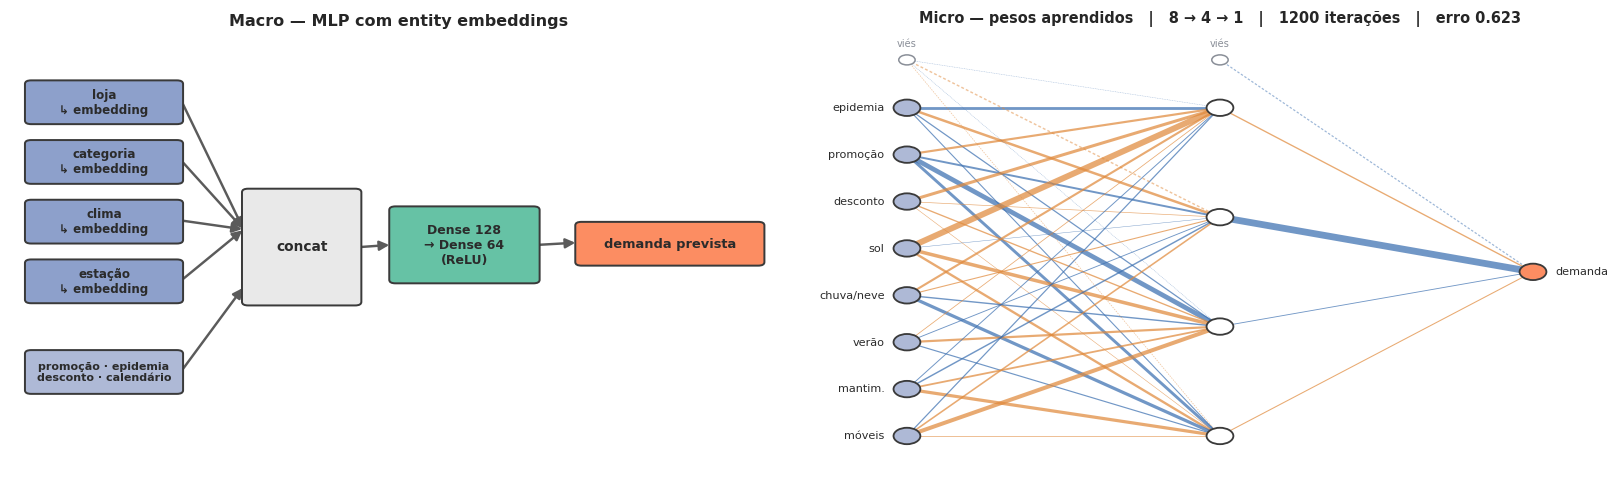

In [4]:
import fase_diagramas as D
D.painel(df, "mlp"); plt.show()

Parou na época 56 | melhor val-loss 0.5667


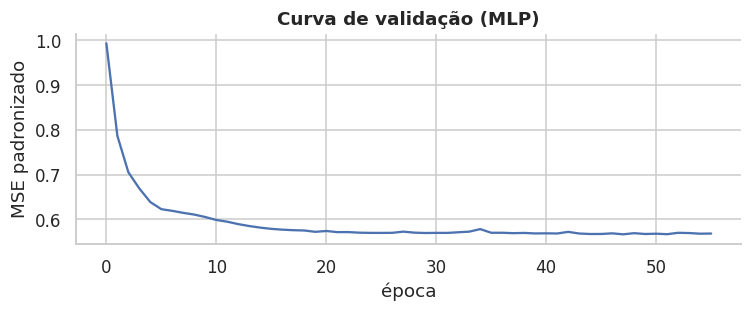

In [5]:
# Treino: Adam, MSE sobre o alvo padronizado, com 10% de validação para early stopping
opt = torch.optim.Adam(rede.parameters(), lr=3e-3, weight_decay=1e-5)
perda = nn.MSELoss()

n = len(y); corte_val = int(n * 0.9); ordem = np.random.permutation(n)
tr_i, val_i = ordem[:corte_val], ordem[corte_val:]
bs, melhor, paciencia, espera = 1024, np.inf, 8, 0
historico = []
for ep in range(60):
    rede.train(); np.random.shuffle(tr_i)
    for b in range(0, len(tr_i), bs):
        j = tr_i[b:b + bs]
        opt.zero_grad()
        out = rede(Xc[j], Xn[j])
        loss = perda((out - y_mu) / y_sd, (y[j] - y_mu) / y_sd)
        loss.backward(); opt.step()
    rede.eval()
    with torch.no_grad():
        vloss = perda((rede(Xc[val_i], Xn[val_i]) - y_mu) / y_sd, (y[val_i] - y_mu) / y_sd).item()
    historico.append(vloss)
    if vloss < melhor - 1e-4:
        melhor, espera, estado = vloss, 0, {k: v.clone() for k, v in rede.state_dict().items()}
    else:
        espera += 1
        if espera >= paciencia:
            break
rede.load_state_dict(estado)
print(f"Parou na época {ep+1} | melhor val-loss {melhor:.4f}")

plt.figure(figsize=(7, 3))
plt.plot(historico, color="#4C72B0")
plt.title("Curva de validação (MLP)"); plt.xlabel("época"); plt.ylabel("MSE padronizado")
sns.despine(); plt.tight_layout(); plt.show()

## 3. A rede bate o gradient boosting?

O teste decisivo: a MLP com *embeddings* supera o RMSSE 0,61 da Trilha A?

+-----------------------------+---------+-------+
| modelo                      |   RMSSE |   MAE |
+=============================+=========+=======+
| naïve (lag 1)               |  0.9542 | 39.64 |
+-----------------------------+---------+-------+
| naïve sazonal (lag 7)       |  1.0252 | 42.78 |
+-----------------------------+---------+-------+
| média do SKU                |  0.7967 | 34.04 |
+-----------------------------+---------+-------+
| GBM global (Trilha A)       |  0.6096 | 25.39 |
+-----------------------------+---------+-------+
| MLP + embeddings (Trilha B) |  0.6126 | 25.52 |
+-----------------------------+---------+-------+


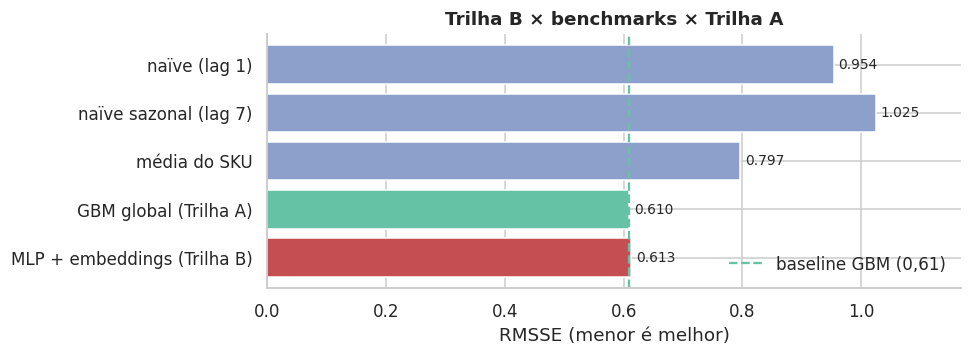

In [6]:
rede.eval()
with torch.no_grad():
    teste["pred_mlp"] = np.maximum(rede(Xc_te, Xn_te).squeeze(1).numpy(), 0)
    treino["pred_mlp"] = np.maximum(rede(Xc, Xn).squeeze(1).numpy(), 0)

rmsse_B = C.rmsse_medio(teste, "pred_mlp", treino)
placar = C.benchmarks(treino, teste)
placar = pd.concat([placar,
    pd.DataFrame([{"modelo": "GBM global (Trilha A)", "RMSSE": 0.6096, "MAE": 25.39},
                  {"modelo": "MLP + embeddings (Trilha B)", "RMSSE": round(rmsse_B, 4),
                   "MAE": round((teste["demanda"] - teste["pred_mlp"]).abs().mean(), 2)}])],
    ignore_index=True)
print(placar.to_markdown(index=False, tablefmt="grid"))

fig, ax = plt.subplots(figsize=(9, 3.4))
cores = ["#8DA0CB"]*3 + ["#66C2A5", "#C44E52"]
b = ax.barh(placar["modelo"], placar["RMSSE"], color=cores)
ax.bar_label(b, fmt="%.3f", padding=3, fontsize=9)
ax.axvline(0.6096, color="#66C2A5", lw=1.5, ls="--", label="baseline GBM (0,61)")
ax.set_xlabel("RMSSE (menor é melhor)"); ax.set_title("Trilha B × benchmarks × Trilha A")
ax.invert_yaxis(); ax.legend(frameon=False, loc="lower right"); ax.margins(x=0.14)
sns.despine(); plt.tight_layout(); plt.show()

A MLP com *embeddings* alcança **RMSSE ≈ 0,61 — empatando com o gradient boosting** e bem acima dos benchmarks. A rede aprende a mesma economia do problema por representações densas das categóricas, mas **não o supera**. É coerente com a M5, onde redes neurais igualaram, mas raramente venceram, o boosting em dados tabulares de varejo: o *embedding* funciona, só não há sinal extra a extrair.

## 4. Resultados — quanto vale, em três níveis de serviço

Aplico exatamente o mesmo método de resultados da Trilha A: transformo a previsão em **pedido de reposição** e mostro o efeito em dinheiro, ajustado pelo parâmetro **τ** (nível de serviço-alvo). Cada previsão de ponto vira um pedido por **calibração de resíduos por SKU** (adiciona-se o quantil τ dos resíduos do próprio SKU), uniforme entre as três trilhas.

In [7]:
base = C.baseline_atual(df, teste)
print(f"Operação ATUAL — ruptura {base['ruptura']:.1%} | "
      f"venda perdida R$ {base['perda']/1e6:.2f} M/ano | capital R$ {base['capital']/1e6:.2f} M\n")

pred_q = C.calibrador_residual(treino, teste, "pred_mlp")     # previsão → pedido no nível τ
tri = C.tres_niveis(df, teste, base, pred_q)
frente = C.fronteira(df, teste, base, pred_q)
print(C.tabela_niveis(base, tri).to_markdown(index=False, tablefmt="grid"))

Operação ATUAL — ruptura 13.3% | venda perdida R$ 12.48 M/ano | capital R$ 1.92 M

+---------------------------------+----------------------+------------------+-------------------+
|                                 | Econômico (τ=0.85)   | Médio (τ=0.95)   | Seguro (τ=0.99)   |
+=================================+======================+==================+===================+
| nível de serviço-alvo (τ)       | 87%                  | 96%              | 99%               |
+---------------------------------+----------------------+------------------+-------------------+
| risco de ruptura                | 13.5%                | 4.2%             | 0.9%              |
+---------------------------------+----------------------+------------------+-------------------+
| venda perdida / ano             | R$ 6.14 M            | R$ 1.76 M        | R$ 0.34 M         |
+---------------------------------+----------------------+------------------+-------------------+
| → economia vs. hoje             |

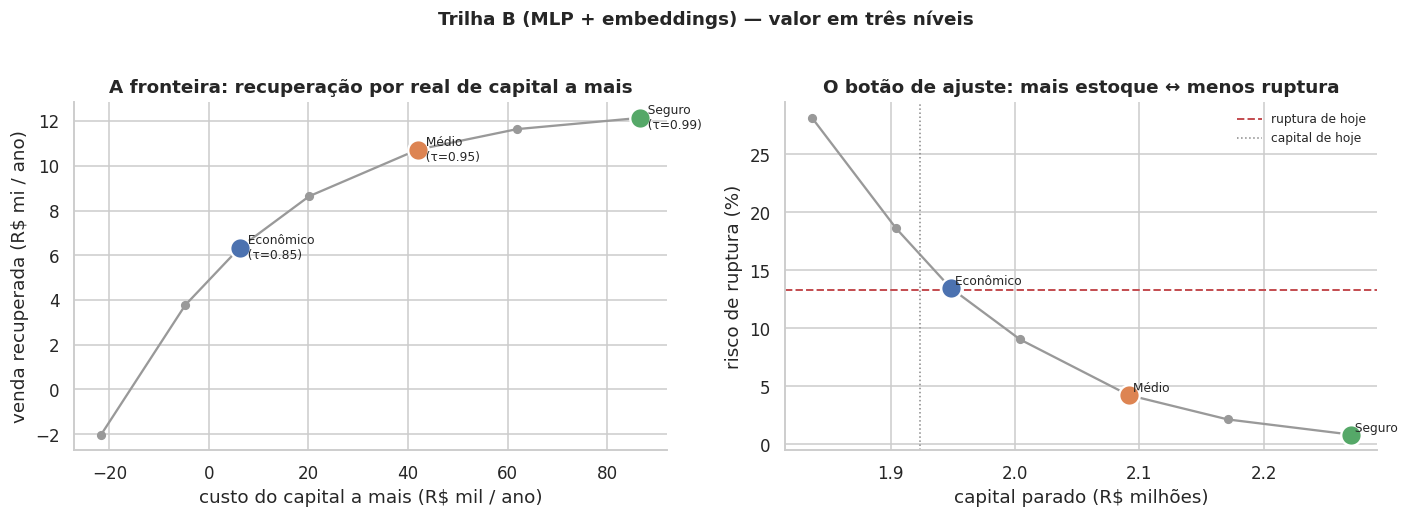

Previsões salvas em resultados/B_redeNeural.csv | RMSSE = 0.6126


In [8]:
C.grafico_resultados(base, frente, tri, titulo="Trilha B (MLP + embeddings) — valor em três níveis")

# Salva as previsões de teste para a comparação em fase1_conclusoes
C.salva_resultado("B_redeNeural", teste, "pred_mlp", round(float(rmsse_B), 4))
print("Previsões salvas em resultados/B_redeNeural.csv | RMSSE =", round(float(rmsse_B), 4))

A tradução em reais é **idêntica à da Trilha A** (mesmo motor de resultados, com preço estável e sensibilidade de carregamento): no nível **Médio (95%)** a rede recupera ~R\$ 10,7 milhões/ano com o capital de hoje, e o botão τ oferece o mesmo trade-off. A rede entrega o resultado, não um resultado melhor.

## 5. Conclusões da Trilha B

A MLP com *entity embeddings* **iguala** o gradient boosting (RMSSE ~0,61) e supera os benchmarks: os *embeddings* de Guo & Berkhahn representam bem as categóricas, mas não extraem sinal além do que o GBM já capta. Em dinheiro, empata — mesma fronteira, mesmos ~R\$ 10,7 M/ano no nível Médio. Como exige padronização, escolha de arquitetura, *early stopping* e mais tempo de treino para entregar o mesmo número, o critério da própria M5 — preferir o modelo mais simples no empate — mantém o **gradient boosting à frente**.

Resta a abordagem mais capaz de explorar o tempo — uma rede convolucional sobre o histórico de cada item.